In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LinearRegression,ElasticNet,Ridge,Lasso,LassoCV
from sklearn.preprocessing import normalize
plt.rcParams["figure.figsize"] = (5,4)
plt.rcParams["figure.dpi"] = 150
TICK_SIZE = 12
AXES_SIZE = 14
TITLE_SIZE = 14
FACECOLOR = 'white'
SCATTER_ALPHA = 0.5

plt.rc('font', size=TICK_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=AXES_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=AXES_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=TICK_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=TICK_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=TICK_SIZE)    # legend fontsize
plt.rc('figure', titlesize=TITLE_SIZE)  # fontsize of the figure title


In [2]:
# loads data :)
# features are - Average Job Power, Average Job Time, Average Job # Nodes, Number of Jobs, Utilization
#
# average job power and time were calculated as the mean of the mean of the 
# minimum and maximum power and time 
NORMALIZE = True
data_folder = 'numpy_data/'
feature_data = np.load(data_folder + 'sim_features.npy')
feature_qos = np.load(data_folder + 'features_qos.npy')
r_labels = np.load(data_folder + 'r_labels.npy')
p_labels = np.load(data_folder + 'p_labels.npy')
# if normalizing
if NORMALIZE:
    r_labels = r_labels / np.sum(r_labels)
    p_labels = p_labels / np.sum(p_labels)
    feature_data = normalize(feature_data,axis=0)
    feature_qos = normalize(feature_qos,axis=0)
# test train split, I guess
feature_train, feature_test, r_train, r_test = train_test_split(feature_data,r_labels, test_size=0.3, random_state=1)
#print(feature_test)
feature_train, feature_test, p_train, p_test = train_test_split(feature_data,p_labels, test_size=0.3, random_state=1)
#print(feature_test)

In [4]:
clf_r = LassoCV().fit(feature_qos, r_labels)
clf_p = LassoCV().fit(feature_qos, p_labels)
r_importance = np.abs(clf_r.coef_)
p_importance = np.abs(clf_p.coef_)
print('R Feat Imp:',r_importance)
print('P Feat Imp:',p_importance)

R Feat Imp: [0.         0.11447804 0.01243579 0.         0.01637124 0.63052897]
P Feat Imp: [0.         0.00127221 0.         0.         0.05415175 0.        ]


In [6]:
p_reduced_features = feature_qos[:,[1,4]]
r_reduced_features =  feature_qos[:,[1,2,4,5]]

In [11]:
p_lin_reg_all = LinearRegression().fit(p_reduced_features, p_labels)
r_lin_reg_all = LinearRegression().fit(r_reduced_features, r_labels)
p_lin_reg_pred_all = p_lin_reg_all.predict(p_reduced_features)
r_lin_reg_pred_all = r_lin_reg_all.predict(r_reduced_features)
print('P MAE:',sklearn.metrics.mean_absolute_error(p_labels,p_lin_reg_pred_all))
print('R MAE:',sklearn.metrics.mean_absolute_error(r_labels,r_lin_reg_pred_all))
print('P R^2:',p_lin_reg_all.score(p_reduced_features,p_labels))
print('R R^2:',r_lin_reg_all.score(r_reduced_features,r_labels))

P MAE: 0.0031110953116902204
R MAE: 0.007061066749912905
P R^2: 0.6505865343895458
R R^2: 0.6854014256568888


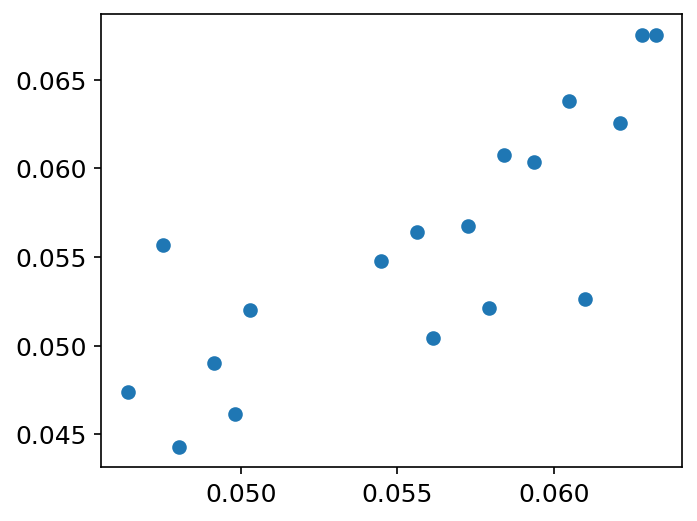

In [25]:
plt.scatter(p_lin_reg_pred_all,p_labels)

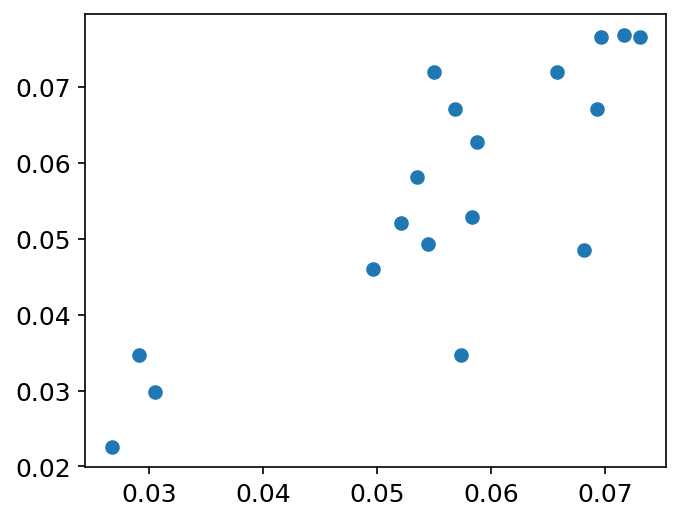

In [26]:
plt.scatter(r_lin_reg_pred_all,r_labels)

In [23]:
### five fold CV ###
from sklearn.metrics import r2_score
split = 0.3
average_p_r2 = 0
average_r_r2 = 0
trials = 10
#normalization_penalty = 0.00001
for i in range(trials):
    feature_train, feature_test, r_train, r_test = train_test_split(r_reduced_features,r_labels, test_size=split, random_state=i)
    feature_train, feature_test, p_train, p_test = train_test_split(p_reduced_features,p_labels, test_size=split, random_state=i)
    p_lin_reg = LassoCV().fit(feature_train, p_train)
    #average_p_r2 += p_lin_reg.score(feature_test, p_test)
    average_p_r2 += r2_score(p_lin_reg.predict(feature_test),p_test)
    r_lin_reg = LassoCV().fit(feature_train, r_train)
    #average_r_r2 += r_lin_reg.score(feature_test, r_test)
    average_r_r2 += r2_score(r_lin_reg.predict(feature_test),r_test)
print('P 5 CV Mean Test R^2',average_p_r2/trials)
print('R 5 CV Mean Test R^2',average_r_r2/trials)

P 5 CV Mean Test R^2 -0.7197655498072537
R 5 CV Mean Test R^2 -5.251027595897891
